# LSTM Networks

Sentiment classification using Long Short Term Memory (LSTM) Networks

## Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt


print("imports done")

imports done


## Load Data

In [ ]:
# for testing purposes
column_1 = 'review' #'text' #name ng column for text
column_2 = 'sentiment' #name ng column for sentiment

train_df = pd.read_csv('data/train.csv').dropna(subset=[column_1])
val_df = pd.read_csv('data/val.csv').dropna(subset=[column_1])
print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")

Train size: 225
Val size: 30


## Preprocess The Text

It is important to preprocess the text info before sending it out to the model to make the process easier. This includes tokenizing the texts, encode the labels into integers, and sequencing it properly

In [3]:
encoder = LabelEncoder()
tokenizer = Tokenizer(num_words=50000, oov_token='XXX') #get top 50,000 common words, oov means out of vocab -- make the token for oov XXX
num_class = 2 #always two since positive or negative only (must be changed if adding neutral)

def preprocess(dataframe):
    info = dataframe[column_1].astype(str).str.lower().str.strip().tolist()
    sentiment = dataframe[column_2].tolist()

    label = encoder.fit_transform(sentiment)

    tokenizer.fit_on_texts(info)
    sequences = tokenizer.texts_to_sequences(info) #convert to sequences
    pad = pad_sequences(sequences, maxlen=800, padding='post', truncating='post') #800 max number of sequence

    return label, pad

train_label, train_pad = preprocess(train_df)
val_label, val_pad = preprocess(val_df)

## Build LSTM Network

In [ ]:
#try to get the smallest as possible
vocab_size = min(50000, len(tokenizer.word_index)+1)

model = Sequential([Embedding(input_dim=vocab_size,
                                output_dim=128,
                                input_length=800),
                    SpatialDropout1D(0.5),
                    Bidirectional(LSTM(128, #hidden units
                                       dropout=0.5,
                                       recurrent_dropout=0.2,
                                       return_sequences=True)),
                    Bidirectional(LSTM(64, #hidden units
                                       dropout=0.5,
                                       recurrent_dropout=0.2)),
                    Dense(64, activation='relu'),
                    Dropout(0.5),
                    Dense(num_class if num_class > 2 else 1,
                            activation="softmax" if num_class > 2 else "sigmoid")])

loss = ("sparse_categorical_crossentropy"
        if num_class > 2 else "binary_crossentropy")

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss,
    metrics=["accuracy"],
)

# model.summary() # empty for now since building palang

c:\Users\Judy Chua\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Train Model

In [8]:
callbacks = [EarlyStopping(patience=3,
                           restore_best_weights=True,
                           monitor="val_loss"),
             ModelCheckpoint("lstm_model.keras",
                             save_best_only=True,
                             monitor="val_loss")]

training = model.fit(train_pad, train_label,
                     validation_data=(val_pad, val_label),
                     epochs=15, batch_size=64,
                     callbacks=callbacks)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.4978 - loss: 0.6932 - val_accuracy: 0.5333 - val_loss: 0.6920
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.5467 - loss: 0.6898 - val_accuracy: 0.5333 - val_loss: 0.6908
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.5511 - loss: 0.6873 - val_accuracy: 0.5333 - val_loss: 0.6914
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 8s/step - accuracy: 0.5556 - loss: 0.6828 - val_accuracy: 0.5333 - val_loss: 0.6936
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 0.5556 - loss: 0.6889 - val_accuracy: 0.5333 - val_loss: 0.6952


Training curves saved → training_curves.png


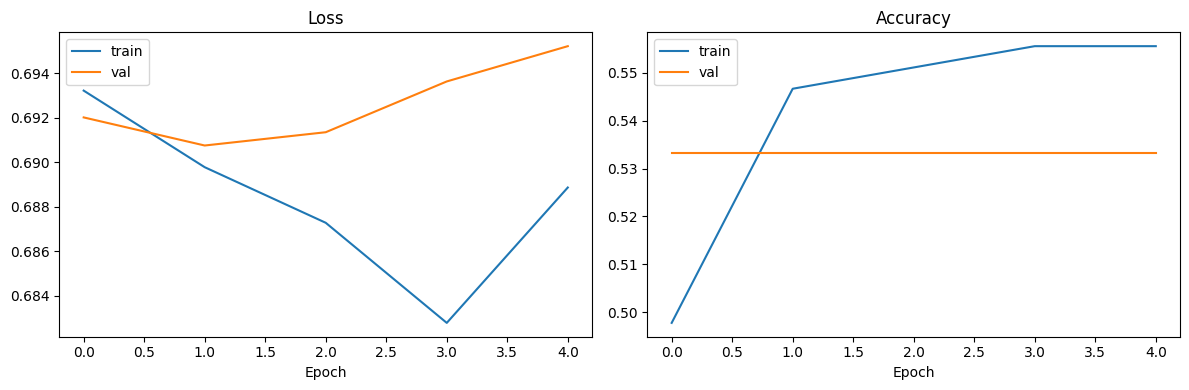

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(training.history[metric], label="train")
    ax.plot(training.history[f"val_{metric}"], label="val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
print("Training curves saved → training_curves.png")
plt.show()

## Evaluate on Testing Set

NOT YET TESTED

In [ ]:
eval_df = pd.read_csv('data/test.csv').dropna(subset=[column_1])
print(f"Test size: {len(eval_df)}")

eval_label, eval_pad = preprocess(eval_df)

eval_loss, eval_acc = model.evaluate(eval_pad, eval_label, verbose=0)
print(f"Test loss is {eval_loss:.4f} while Test accuracy is {eval_acc:.4f}")

preds_raw = model.predict(eval_pad)
preds = (preds_raw.squeeze() >= 0.5).astype(int)

print(classification_report(eval_label, preds, target_names=[str(c) for c in encoder.classes_]))